#### Stein Variational Gradient Descent
+ This notebook is for Stein Variational Inference:
+ target posterior $p(w|x^n)$ is approximated by $q(w)$ based on Stein Discrepancy $D(p, q)$:
$$
D(p, q) := \max_{\phi \in F} E_{w \sim q} [tr(A_{p}\phi(w))],
$$
+ where $A_p$ is stein's operator: $A_{p} \phi(w) = \nabla_w \log p^T(w|x^n) \phi(w) + \nabla_w \phi(w)$.
+ When $F$ is RKHS on $d$-dimensional, and the approximated distribution is $q(z)$, where $z = T(x) = x + \epsilon \phi(x)$,
+ then the the maximum direction $\phi^*_{q,p}$ of $\frac{d}{d\epsilon}KL(q|p) |_{\epsilon=0}$ is given by 
$$
\phi^*_{q,p}(\cdot) = E_{w \sim q} [tr(A_p k(w,\cdot))] \approx \sum_{l=1}^L \frac{1}{L} \Bigl\{ \nabla_w \log p(w_l|x^n) k(w_l,\cdot) + \nabla_w k(w_l, \cdot) \Bigr\}
$$

+ Based on the value, the sample of the posterior distribution $w^{(l)}$ is calculated iteratively:
$$
w^{(l+1)} = w^{(l)} + \epsilon \phi^*{q,p}(w^{(l)})
$$
+ where $\epsilon$ is step size, and should be gradually descreased like conventional gradient descent method.

# First Step
+ Check Algorithm by simple case
+ Here, we consider about a posterior for mean of multivariate gaussian distribution:
$$
p(w|x^n) \propto p(\mu) \prod_{i=1}^n N(x_i|\mu, I_M)
$$

In [1]:
%matplotlib inline

In [2]:
import numpy as np
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt

## Data Generation

In [3]:
## dimension of input
M = 2

# number of samples
n = 100

data_seed = 20241229
np.random.seed(data_seed)

true_mu = np.array([-10, 10])
train_X = np.random.multivariate_normal(true_mu, np.eye(M), size=n)

## Hyperparameters
+ kernel function: Radial Basis Kernel $\exp(-\|x - y\|^2 / 2h^2)$
+ prior: multivariate distribution $N(\mu|0, \beta^{-1} I_M)$
+ initial samples: $w \sim q_0(w)$, where $w \in R^{L \times M}$, $L$ is the number of sample from the approximated posterior

In [4]:
ln_seed = 20241231
np.random.seed(ln_seed)

pri_beta = 1

L = 100
initial_post_param = np.random.normal(size = (L, M))

h = 1
first_step_size = 0.05

### Calculate gradient of first update
+ Note: In the algorithm, $\sum_i \nabla_{w_i} k(w_i, w_j)$ is necessary, and the result is $L \times M$.

In [5]:
# ite = 0

# post_param = initial_post_param.copy()

# # radial basis kernel is used here
# h = 1
# kernel_post = np.exp(-squareform(pdist(post_param))/(2*h**2))

# dw_kernel_post = (-kernel_post.T @ post_param + kernel_post.sum(axis=0)[:,np.newaxis] * post_param) / (h**2)

# # debug
# target = np.zeros((L, M))
# for j in range(L):
#     for k in range(M):
#         target[j,k] = (-post_param[:,k]*kernel_post[:,j] + post_param[j,k]*kernel_post[:,j]).sum() / (h**2)
#         pass

# # gradient of log posterior
# dw_logp = (train_X.sum(axis=0)[np.newaxis,:] - (n + 1/pri_beta)*post_param)

# # gradient of target functional
# phi_post_param = (dw_logp + dw_kernel_post) / L

# plt.scatter(post_param[:,0], post_param[:,1])
# plt.show()

# plt.scatter(phi_post_param[:,0], phi_post_param[:,1])
# plt.show()

## Original method
+ Here, we simply use the algorithm

In [6]:
n_ite = 1000
post_param = initial_post_param.copy()

disp_cycle = 100

h = 0.1
for ite in range(n_ite):
    dist = pdist(post_param)
    
    # radial basis kernel is used here
    kernel_post = np.exp(-squareform(dist)/(2*h**2))

    # gradient of kernel function
    dw_kernel_post = (-kernel_post.T @ post_param + kernel_post.sum(axis=0)[:,np.newaxis] * post_param) / (h**2)
    
    # gradient of log posterior
    dw_logp = (train_X.sum(axis=0)[np.newaxis,:] - (n + pri_beta)*post_param)
    
    # gradient of target functional
    phi_post_param = (kernel_post.T @ dw_logp + dw_kernel_post) / L

    # sample update
    step_size = first_step_size
    post_param = post_param + step_size * phi_post_param

    if ite % disp_cycle == 0:
        print("ite = {}, post_param = {}, h = {}".format(ite, post_param[0], h))
    pass

ite = 0, post_param = [-1.00429099 -0.09579019], h = 0.1
ite = 100, post_param = [-9.82333095  9.78532295], h = 0.1
ite = 200, post_param = [-9.82394531  9.78616042], h = 0.1
ite = 300, post_param = [-9.82524589  9.78540421], h = 0.1
ite = 400, post_param = [-9.82546406  9.78523   ], h = 0.1
ite = 500, post_param = [-9.82535343  9.78546633], h = 0.1
ite = 600, post_param = [-9.82526578  9.78566525], h = 0.1
ite = 700, post_param = [-9.82525367  9.78572612], h = 0.1
ite = 800, post_param = [-9.82531254  9.78569038], h = 0.1
ite = 900, post_param = [-9.82542785  9.78560146], h = 0.1


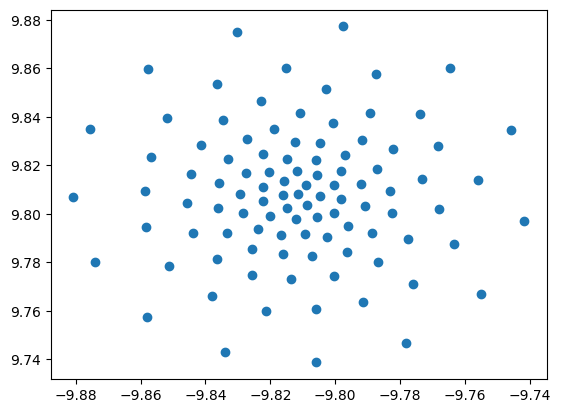

In [7]:
plt.scatter(post_param[:,0], post_param[:,1])
plt.show()

## Plus RMSProp and adjust band width
+ We utilize the RMSProp to adjust step size of the functional gradient

In [8]:
n_ite = 2000
post_param = initial_post_param.copy()

disp_cycle = 100

alpha = 0.9
# step_size = 1e-2
jitter = 1e-6
r_t = 0
for ite in range(n_ite):
    dist = pdist(post_param)
    h = np.sqrt(0.5*np.median(dist)**2/np.log(L))
    
    # radial basis kernel is used here
    kernel_post = np.exp(-squareform(dist)/(2*h**2))

    # gradient of kernel function
    dw_kernel_post = (-kernel_post.T @ post_param + kernel_post.sum(axis=0)[:,np.newaxis] * post_param) / (h**2)
    
    # gradient of log posterior
    dw_logp = (train_X.sum(axis=0)[np.newaxis,:] - (n + pri_beta)*post_param)
    
    # gradient of target functional
    phi_post_param = (kernel_post.T @ dw_logp + dw_kernel_post) / L

    # sample update
    if ite == 0:
        r_t = phi_post_param**2
    else:    
        r_t = alpha * r_t + (1 - alpha) * phi_post_param**2
    
    step_size = first_step_size / np.sqrt(r_t + jitter)
    post_param = post_param + step_size * phi_post_param

    if ite % disp_cycle == 0:
        print("ite = {}, post_param = {}, h = {}, eta_t = {}".format(ite, post_param[0], h, step_size[0]))
    pass

ite = 0, post_param = [-0.58587376 -0.57252822], h = 0.5536466526065975, eta_t = [0.00031841 0.00029951]
ite = 100, post_param = [-5.29268183  4.15698466], h = 0.5424211952310418, eta_t = [0.00059558 0.00053473]
ite = 200, post_param = [-9.32884844  8.3820805 ], h = 0.4429089715168785, eta_t = [0.00375327 0.00248557]
ite = 300, post_param = [-9.81146278  9.80703842], h = 0.0025865846391874394, eta_t = [0.62486588 0.26930076]
ite = 400, post_param = [-9.8335611   9.78570539], h = 0.018185610111434766, eta_t = [1.77980301 1.68178085]
ite = 500, post_param = [-9.86006775  9.77488376], h = 0.019117770553308194, eta_t = [1.43414482 1.55196393]
ite = 600, post_param = [-9.82746635  9.82268396], h = 0.022914489148941047, eta_t = [1.23713501 1.21770355]
ite = 700, post_param = [-9.77800769  9.84747433], h = 0.022602077788037914, eta_t = [2.37774747 1.88480742]
ite = 800, post_param = [-9.8332653   9.84396199], h = 0.023369423640944274, eta_t = [1.94504187 1.70891053]
ite = 900, post_param = [-

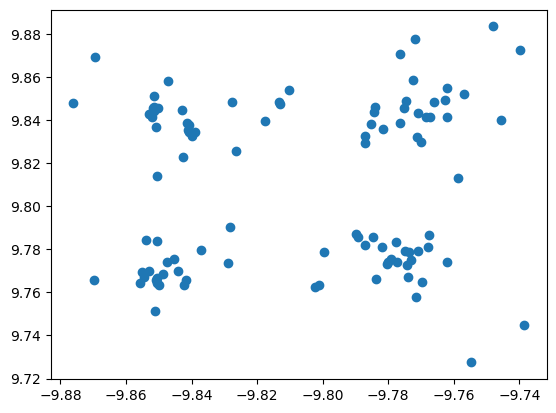

In [9]:
plt.scatter(post_param[:,0], post_param[:,1])
plt.show()

# compare with true posterior
+ In the setting, the true posterior $p(w|x^n)$ is calculated by
$$
p(w|x^n) = N(w|\hat{\mu}, \hat{\beta}^{-1} I_M), \\
\hat{\beta} = n + \beta, \\
\hat{\mu} = \frac{1}{\hat{\beta}} \sum_i x_i
$$

In [10]:
true_post_beta = n + pri_beta
true_post_mu = train_X.sum(axis=0) / true_post_beta

In [11]:
true_post = np.random.multivariate_normal(true_post_mu, 1/true_post_beta * np.eye(M), size=100)

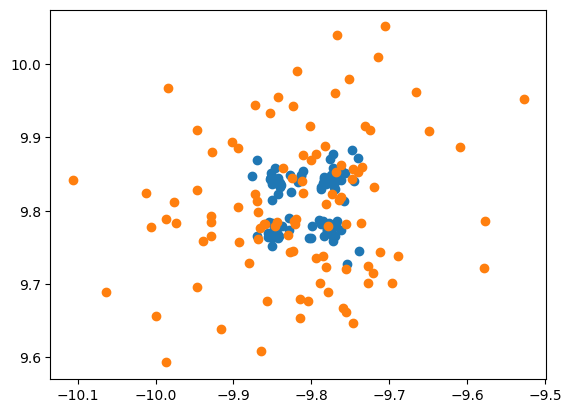

In [12]:
plt.scatter(post_param[:,0], post_param[:,1])
plt.scatter(true_post[:,0], true_post[:,1])
plt.show()

# Next Step: Logistic regression
+ Next we consider about logistic regression
+ Basically, it is same calculation except for derivative of log posterior

In [13]:
from scipy.special import expit

## Data Generation

In [14]:
## dimension of input
M = 5

# number of samples
n = 100

data_seed = 20241229
np.random.seed(data_seed)

true_w = np.random.normal(size=M)

train_X = np.random.normal(size=(n,M))
train_Y = np.random.binomial(1, expit(train_X @ true_w))

## Hyperparameters
+ kernel function: Radial Basis Kernel $\exp(-\|x - y\|^2 / 2h^2)$
+ prior: multivariate distribution $N(\mu|0, \beta^{-1} I_M)$
+ initial samples: $w \sim q_0(w)$, where $w \in R^{L \times M}$, $L$ is the number of sample from the approximated posterior

In [15]:
ln_seed = 20241231
np.random.seed(ln_seed)

pri_beta = 1

L = 100
initial_post_param = np.random.normal(size = (L, M))

h = 1
first_step_size = 0.05

## Learning
+ Change a derivative part of the posterior

In [16]:
n_ite = 5000
post_param = initial_post_param.copy()

disp_cycle = 100

alpha = 0.9
# step_size = 1e-2
jitter = 1e-6
r_t = 0
for ite in range(n_ite):
    dist = pdist(post_param)
    h = np.sqrt(0.5*np.median(dist)**2/np.log(L))
    
    # radial basis kernel is used here
    kernel_post = np.exp(-squareform(dist)/(2*h**2))

    # gradient of kernel function
    dw_kernel_post = (-kernel_post.T @ post_param + kernel_post.sum(axis=0)[:,np.newaxis] * post_param) / (h**2)
    
    # gradient of log posterior
    dw_logp = (train_Y[np.newaxis,:]-expit(post_param @ train_X.T))@train_X - pri_beta*post_param
    
    # gradient of target functional
    phi_post_param = (kernel_post.T @ dw_logp + dw_kernel_post) / L

    # sample update
    if ite == 0:
        r_t = phi_post_param**2
    else:    
        r_t = alpha * r_t + (1 - alpha) * phi_post_param**2
    
    # step_size = first_step_size / (ite + 1)
    # step_size = first_step_size
    step_size = first_step_size / np.sqrt(r_t + jitter)
    post_param = post_param + step_size * phi_post_param

    if ite % disp_cycle == 0:
        print("ite = {}, post_param = {}, h = {}, step_size = {}".format(ite, post_param[0], h, step_size[0]))
    pass

ite = 0, post_param = [-0.58587376 -0.67252821 -0.34739503 -1.64420225  0.01277199], h = 0.9732267476637254, step_size = [0.00928524 0.01973841 0.03811722 0.16367484 0.24109917]
ite = 100, post_param = [-1.86029664 -0.97919191 -0.77040071  0.06912213  0.42661671], h = 0.07987812983542665, step_size = [ 0.6970692   2.75852749  5.57344062  9.78619626 15.65761789]
ite = 200, post_param = [-1.717753   -0.93884993 -0.7620671   0.06473174  0.34083087], h = 0.02359761485886434, step_size = [10.5339401   7.25878367 10.45316618 10.689423   10.8573719 ]
ite = 300, post_param = [-1.71159624 -0.95283069 -0.75495948  0.06619655  0.3307628 ], h = 0.022430723985536243, step_size = [10.70167527  8.21701294  9.8397731   9.66268858 10.98143947]
ite = 400, post_param = [-1.71859936 -0.94533294 -0.75408632  0.07397211  0.33962771], h = 0.023276684779754205, step_size = [11.1047933   8.28118515 10.02897292 12.33504346 11.43074534]
ite = 500, post_param = [-1.71858369 -0.95763613 -0.73621769  0.0736653   0.

In [17]:
true_w

array([-1.69021652, -1.50911208, -0.7582608 , -0.19483659,  0.55051277])

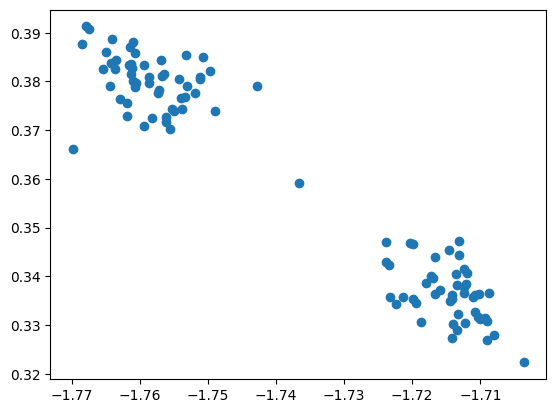

In [18]:
plt.scatter(post_param[:,0], post_param[:,4])
plt.show()

# Next Step: Singular model
+ As a test case of sigular model, we consider about the following model:
$$
p(y|x,a,b) = N(y|a \tanh(bx), 1)
$$
+ When $a=0$ or $b=0$, the model is singular.

## Data Generation

In [37]:
## dimension of input
M = 1

# number of samples
n = 400

data_seed = 20241229
np.random.seed(data_seed)

true_a = 0 #np.random.normal(size=1)
true_b = 0 #np.random.normal(size=1)

train_X = np.random.normal(size=(n,M))
train_Y = true_a * np.tanh(true_b * train_X) + np.random.normal(size=(n,1))
# train_Y = np.random.binomial(1, expit(train_X @ true_w))

## Hyperparameters
+ kernel function: Radial Basis Kernel $\exp(-\|x - y\|^2 / 2h^2)$
+ prior: multivariate distribution $N((a,b)|0, \beta^{-1} I_M)$
+ initial samples: $w \sim q_0(w)$, where $w \in R^{L \times 2}$, $L$ is the number of sample from the approximated posterior

In [38]:
ln_seed = 20241231
np.random.seed(ln_seed)

pri_beta = 1

L = 100
initial_post_param = np.random.normal(size = (L, 2))

h = 1
first_step_size = 0.05

## Learning
+ Change a derivative part of the posterior

In [39]:
n_ite = 1000
post_param = initial_post_param.copy()

disp_cycle = 100

alpha = 0.9
# step_size = 1e-2
jitter = 1e-6
r_t = 0
for ite in range(n_ite):
    dist = pdist(post_param)
    h = np.sqrt(0.5*np.median(dist)**2/np.log(L))
    
    # radial basis kernel is used here
    kernel_post = np.exp(-squareform(dist)/(2*h**2))

    # gradient of kernel function
    dw_kernel_post = (-kernel_post.T @ post_param + kernel_post.sum(axis=0)[:,np.newaxis] * post_param) / (h**2)
    
    # gradient of log posterior
    proc_train_X = train_X.squeeze()[:,np.newaxis]
    proc_train_Y = train_Y.squeeze()[:,np.newaxis]
    residual = proc_train_Y - post_param[:,0][np.newaxis,:] * np.tanh(post_param[:,1][np.newaxis,:] * proc_train_X)
    dw_logpy = np.array([
        (residual * (np.tanh(post_param[:,1][np.newaxis,:] * proc_train_X))).sum(axis=0),
        (residual * (post_param[:,0][np.newaxis,:] * proc_train_X / np.cosh(post_param[:,1][np.newaxis,:] * proc_train_X)**2)).sum(axis=0),
    ]).T
    dw_logp = dw_logpy - pri_beta*post_param
    
    # gradient of target functional
    phi_post_param = (kernel_post.T @ dw_logp + dw_kernel_post) / L

    # # calc stein discrepancy
    # dw_partial_kernel = -1/h**2 * (post_param[np.newaxis,:,:] - post_param[:,np.newaxis,:]) * kernel_post[:,:,np.newaxis]
    # dwdw_kernel = (1/h**2 * kernel_post[:,:,np.newaxis] * (1+(post_param[np.newaxis,:,:] - post_param[:,np.newaxis,:])**2 / (2*h**2) ))
    # # divergence of phi
    # div_phi = (dw_logp[np.newaxis,:,:] * dw_partial_kernel + dwdw_kernel).sum(axis=2).mean()
    # dw_logp_phi = (dw_logp * phi_post_param).sum(axis=1).mean()
    # stein_discrepancy = dw_logp_phi + div_phi
    
    # sample update
    if ite == 0:
        r_t = phi_post_param**2
    else:    
        r_t = alpha * r_t + (1 - alpha) * phi_post_param**2
    
    # step_size = first_step_size / (ite + 1)
    # step_size = first_step_size
    step_size = first_step_size / np.sqrt(r_t + jitter)
    post_param = post_param + step_size * phi_post_param

    if ite % disp_cycle == 0:
        print("ite = {}, post_param = {}, h = {}, step_size = {}".format(ite, post_param[0], h, step_size[0]))
    pass

ite = 0, post_param = [-0.48587376 -0.57252822], h = 0.5536466526065975, step_size = [0.01799582 0.02121917]
ite = 100, post_param = [-0.03253138 -0.5333979 ], h = 0.4061756800034173, step_size = [0.25222582 0.5256308 ]
ite = 200, post_param = [-0.01848085 -0.83027507], h = 0.8146538693959596, step_size = [0.06276928 0.02018706]
ite = 300, post_param = [-0.01222727 -0.90944083], h = 0.9407592036083815, step_size = [0.05149276 0.01122102]
ite = 400, post_param = [-0.00684345 -0.95923161], h = 1.0128986161295714, step_size = [0.04668682 0.00842161]
ite = 500, post_param = [-0.00255446 -0.99810718], h = 1.0622017825825334, step_size = [0.0440263 0.00705  ]
ite = 600, post_param = [ 0.0010777  -1.03117661], h = 1.1018499985077028, step_size = [0.04216088 0.00619276]
ite = 700, post_param = [ 0.00415161 -1.06054567], h = 1.1348484733154394, step_size = [0.04074449 0.00559591]
ite = 800, post_param = [ 0.006809   -1.08723485], h = 1.1638320396874033, step_size = [0.03956799 0.00513814]
ite =

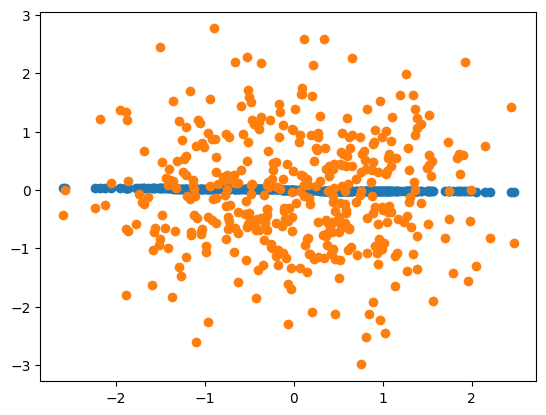

In [40]:
plt.scatter(
    train_X.squeeze(),
    (post_param[:,0][np.newaxis,:] * np.tanh(proc_train_X * post_param[:,1][np.newaxis,:])).mean(axis=1),
)
plt.scatter(
    train_X.squeeze(),
    train_Y.squeeze(),
)
plt.show()

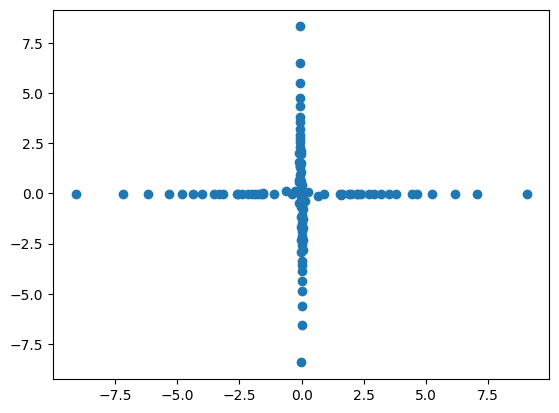

In [41]:
# target_ind = post_param[:,0] > 2
# plt.scatter(post_param[target_ind,0], post_param[target_ind,1])
# target_ind = post_param[:,0] > 2
plt.scatter(post_param[:,0], post_param[:,1])
plt.show()

## Compare with MAP result
+ In the case $L=1$, we can get MAP result

## Data Generation

In [26]:
## dimension of input
M = 1

# number of samples
n = 400

data_seed = 20241229
np.random.seed(data_seed)

true_a = 0 #np.random.normal(size=1)
true_b = 0 #np.random.normal(size=1)

train_X = np.random.normal(size=(n,M))
train_Y = true_a * np.tanh(true_b * train_X) + np.random.normal(size=(n,1))
# train_Y = np.random.binomial(1, expit(train_X @ true_w))

## Hyperparameters
+ kernel function: Radial Basis Kernel $\exp(-\|x - y\|^2 / 2h^2)$
+ prior: multivariate distribution $N((a,b)|0, \beta^{-1} I_M)$
+ initial samples: $w \sim q_0(w)$, where $w \in R^{L \times 2}$, $L$ is the number of sample from the approximated posterior

In [27]:
ln_seed = 20241231
np.random.seed(ln_seed)

pri_beta = 1

L = 1
initial_post_param = np.random.normal(size = (L, 2))

h = 1
first_step_size = 0.05

## Learning
+ Change a derivative part of the posterior

In [33]:
n_ite = 1000
post_param = initial_post_param.copy()

disp_cycle = 100

alpha = 0.9
# step_size = 1e-2
jitter = 1e-6
r_t = 0
for ite in range(n_ite):
    dist = pdist(post_param)
    # h = np.sqrt(0.5*np.median(dist)**2/np.log(L))
    h=1
    
    # radial basis kernel is used here
    kernel_post = np.exp(-squareform(dist)/(2*h**2))

    # gradient of kernel function
    dw_kernel_post = (-kernel_post.T @ post_param + kernel_post.sum(axis=0)[:,np.newaxis] * post_param) / (h**2)
    
    # gradient of log posterior
    proc_train_X = train_X.squeeze()[:,np.newaxis]
    proc_train_Y = train_Y.squeeze()[:,np.newaxis]
    residual = proc_train_Y - post_param[:,0][np.newaxis,:] * np.tanh(post_param[:,1][np.newaxis,:] * proc_train_X)
    dw_logpy = np.array([
        (residual * (np.tanh(post_param[:,1][np.newaxis,:] * proc_train_X))).sum(axis=0),
        (residual * (post_param[:,0][np.newaxis,:] * proc_train_X / np.cosh(post_param[:,1][np.newaxis,:] * proc_train_X)**2)).sum(axis=0),
    ]).T
    dw_logp = dw_logpy - pri_beta*post_param
    
    # gradient of target functional
    phi_post_param = (kernel_post.T @ dw_logp + dw_kernel_post) / L
    
    # sample update
    if ite == 0:
        r_t = phi_post_param**2
    else:    
        r_t = alpha * r_t + (1 - alpha) * phi_post_param**2
    
    step_size = first_step_size / np.sqrt(r_t + jitter)
    post_param = post_param + step_size * phi_post_param

    if ite % disp_cycle == 0:
        print("ite = {}, post_param = {}, dw_logp = {}, h = {}, step_size = {}".format(ite, post_param[0], dw_logp[0], h, step_size[0]))

ite = 0, post_param = [-0.48587376 -0.57252822], dw_logp = [55.66374478 33.55158296], h = 1, step_size = [0.00089825 0.00149024]
ite = 100, post_param = [-0.09234909  0.0986892 ], dw_logp = [-1.05532048e-04 -6.79530538e-05], h = 1, step_size = [0.14694224 0.23200961]
ite = 200, post_param = [-0.04747039  0.05072385], dw_logp = [ 0.14911387 -0.12946266], h = 1, step_size = [0.42062633 0.48661391]
ite = 300, post_param = [-0.11405524  0.1192044 ], dw_logp = [-0.12190392  0.10392973], h = 1, step_size = [0.40158147 0.46341002]
ite = 400, post_param = [-0.06454822  0.07046676], dw_logp = [ 0.09152942 -0.0801891 ], h = 1, step_size = [0.42383671 0.48856327]
ite = 500, post_param = [-0.10800281  0.11453641], dw_logp = [-0.06486005  0.06618594], h = 1, step_size = [0.39483226 0.45290133]
ite = 600, post_param = [-0.11122243  0.11814106], dw_logp = [-0.08840873  0.0899798 ], h = 1, step_size = [0.39123302 0.44740387]
ite = 700, post_param = [ 0.03923389 -0.04612939], dw_logp = [-0.18973346  0.

In [34]:
post_param

array([[ 0.04435562, -0.04961264]])

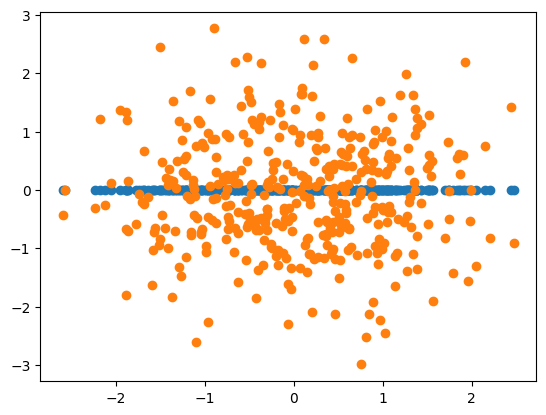

In [35]:
plt.scatter(
    train_X.squeeze(),
    (post_param[:,0][np.newaxis,:] * np.tanh(proc_train_X * post_param[:,1][np.newaxis,:])).mean(axis=1),
)
plt.scatter(
    train_X.squeeze(),
    train_Y.squeeze(),
)
plt.show()

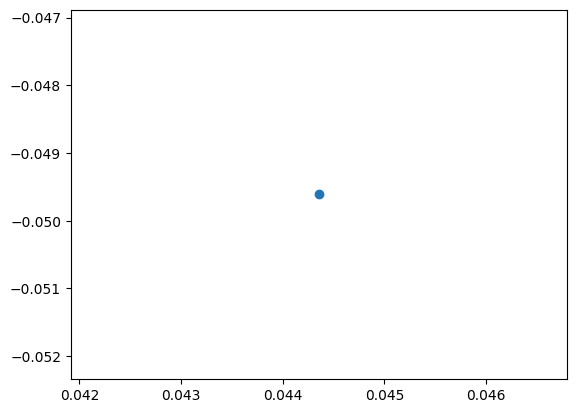

In [36]:
# target_ind = post_param[:,0] > 2
# plt.scatter(post_param[target_ind,0], post_param[target_ind,1])
# target_ind = post_param[:,0] > 2
plt.scatter(post_param[:,0], post_param[:,1])
plt.show()

In [ ]:
# dist = pdist(post_param)

# # radial basis kernel is used here
# kernel_post = np.exp(-squareform(dist)/(2*h**2))

# # gradient of kernel function
# dw_kernel_post = (-kernel_post.T @ post_param + kernel_post.sum(axis=0)[:,np.newaxis] * post_param) / (h**2)

# # gradient of log posterior
# dw_logp = (train_X.sum(axis=0)[np.newaxis,:] - (n + 1/pri_beta)*post_param)

# # gradient of target functional
# phi_post_param = (kernel_post.T @ dw_logp + dw_kernel_post) / L

# dw_partial_kernel = -2/h * (post_param[np.newaxis,:,:] - post_param[:,np.newaxis,:]) * kernel_post[:,:,np.newaxis]
# dwdw_kernel = (2/h * kernel_post[:,:,np.newaxis] * (1+(post_param[np.newaxis,:,:] - post_param[:,np.newaxis,:])**2/h))

# # divergence of phi
# div_phi = (dw_logp[np.newaxis,:,:] * dw_partial_kernel + dwdw_kernel).sum(axis=2).mean()

# dw_logp_phi = (dw_logp * phi_post_param).sum(axis=1).mean()

# stein_discrepancy = dw_logp_phi + div_phi

# stein_discrepancy





# # Next Step: confirm the objective function is optimized
# # + Stein Discrepancy $D(q, p)$ is
# # $$
# # D(q, p) = E_{w \sim q} [\nabla_w \log p(w)^T \phi(w) + \nabla_w \cdot \phi(w)]
# # $$
# # + $phi(w)$ is obtained by the above alogorithm, and expected value is calculated by the samples from the approximated posterior.
# # + Therefore, we can calculate the quantity.
# # + Here, we consider about multivariate normal distribution as a target posterior.

# ## Data Generation

# ## dimension of input
# M = 2

# # number of samples
# n = 50

# data_seed = 20241229
# np.random.seed(data_seed)

# true_mu = np.array([-10, 10])
# train_X = np.random.multivariate_normal(true_mu, np.eye(M), size=n)

# ## Hyperparameters
# # + kernel function: Radial Basis Kernel $\exp(-\|x - y\|^2 / 2h^2)$
# # + prior: multivariate distribution $N(\mu|0, \beta^{-1} I_M)$
# # + initial samples: $w \sim q_0(w)$, where $w \in R^{L \times M}$, $L$ is the number of sample from the approximated posterior

# ln_seed = 20241231
# np.random.seed(ln_seed)

# pri_beta = 2

# L = 100
# initial_post_param = np.random.normal(size = (L, M))

# h = 1
# first_step_size = 0.05

# ## Original method
# # + Here, we simply use the algorithm

# n_ite = 1000
# post_param = initial_post_param.copy()

# disp_cycle = 100

# h = 1
# for ite in range(n_ite):
#     dist = pdist(post_param)
    
#     # radial basis kernel is used here
#     kernel_post = np.exp(-squareform(dist)/(2*h**2))

#     # gradient of kernel function
#     dw_kernel_post = (-kernel_post.T @ post_param + kernel_post.sum(axis=0)[:,np.newaxis] * post_param) / (h**2)
    
#     # gradient of log posterior
#     dw_logp = (train_X.sum(axis=0)[np.newaxis,:] - (n + pri_beta)*post_param)
    
#     # gradient of target functional
#     phi_post_param = (kernel_post.T @ dw_logp + dw_kernel_post) / L

#     # sample update
#     # step_size = first_step_size / (ite + 1)
#     step_size = first_step_size
#     post_param = post_param + step_size * phi_post_param

#     # # calc stein discrepancy
#     # dw_partial_kernel = -2/h * (post_param[np.newaxis,:,:] - post_param[:,np.newaxis,:]) * kernel_post[:,:,np.newaxis]
#     # dwdw_kernel = (2/h * kernel_post[:,:,np.newaxis] * (1+(post_param[np.newaxis,:,:] - post_param[:,np.newaxis,:])**2/h))
    
#     # # divergence of phi
#     # div_phi = (dw_logp[np.newaxis,:,:] * dw_partial_kernel + dwdw_kernel).sum(axis=2).mean()
    
#     # calc stein discrepancy
#     dw_partial_kernel = -1/h**2 * (post_param[np.newaxis,:,:] - post_param[:,np.newaxis,:]) * kernel_post[:,:,np.newaxis]
#     dwdw_kernel = (1/h**2 * kernel_post[:,:,np.newaxis] * (1+(post_param[np.newaxis,:,:] - post_param[:,np.newaxis,:])**2 / (2*h**2) ))
#     # divergence of phi
#     div_phi = (dw_logp[np.newaxis,:,:] * dw_partial_kernel + dwdw_kernel).sum(axis=2).mean()
#     dw_logp_phi = (dw_logp * phi_post_param).sum(axis=1).mean()
#     stein_discrepancy = dw_logp_phi + div_phi
    
#     if ite % disp_cycle == 0:
#         print("ite = {}, post_param = {}, h = {}, stein_discrepancy = {}".format(ite, post_param[0], h, stein_discrepancy))
#     pass

# plt.scatter(post_param[:,0], post_param[:,1])
# plt.show()

# n_ite = 5000
# post_param = initial_post_param.copy()

# disp_cycle = 100

# alpha = 0.9
# # step_size = 1e-2
# jitter = 1e-6
# r_t = 0
# for ite in range(n_ite):
#     dist = pdist(post_param)
#     h = np.sqrt(0.5*np.median(dist)**2/np.log(L))
    
#     # radial basis kernel is used here
#     kernel_post = np.exp(-squareform(dist)/(2*h**2))

#     # gradient of kernel function
#     dw_kernel_post = (-kernel_post.T @ post_param + kernel_post.sum(axis=0)[:,np.newaxis] * post_param) / (h**2)
    
#     # gradient of log posterior
#     dw_logp = (train_X.sum(axis=0)[np.newaxis,:] - (n + 1/pri_beta)*post_param)
    
#     # gradient of target functional
#     phi_post_param = (kernel_post.T @ dw_logp + dw_kernel_post) / L

#     # sample update
#     if ite == 0:
#         r_t = phi_post_param**2
#     else:    
#         r_t = alpha * r_t + (1 - alpha) * phi_post_param**2
    
#     # step_size = first_step_size / (ite + 1)
#     # step_size = first_step_size
#     step_size = first_step_size / np.sqrt(r_t + jitter)
#     post_param = post_param + step_size * phi_post_param

#     # calc stein discrepancy
#     dw_partial_kernel = -1/h**2 * (post_param[np.newaxis,:,:] - post_param[:,np.newaxis,:]) * kernel_post[:,:,np.newaxis]
#     dwdw_kernel = (1/h**2 * kernel_post[:,:,np.newaxis] * (1+(post_param[np.newaxis,:,:] - post_param[:,np.newaxis,:])**2 / (2*h**2) ))
#     # divergence of phi
#     div_phi = (dw_logp[np.newaxis,:,:] * dw_partial_kernel + dwdw_kernel).sum(axis=2).mean()
#     dw_logp_phi = (dw_logp * phi_post_param).sum(axis=1).mean()
#     stein_discrepancy = dw_logp_phi + div_phi    
#     # # calc stein discrepancy
#     # dw_partial_kernel = -2/h * (post_param[np.newaxis,:,:] - post_param[:,np.newaxis,:]) * kernel_post[:,:,np.newaxis]
#     # dwdw_kernel = (2/h * kernel_post[:,:,np.newaxis] * (1+(post_param[np.newaxis,:,:] - post_param[:,np.newaxis,:])**2/h))
#     # # divergence of phi
#     # div_phi = (dw_logp[np.newaxis,:,:] * dw_partial_kernel + dwdw_kernel).sum(axis=2).mean()
#     # dw_logp_phi = (dw_logp * phi_post_param).sum(axis=1).mean()
#     # stein_discrepancy = dw_logp_phi + div_phi
    
#     if ite % disp_cycle == 0:
#         print("ite = {}, post_param = {}, h = {}, eta_t = {}, stein_discrepancy = {}".format(ite, post_param[0], h, step_size[0], stein_discrepancy))
#     pass

# plt.scatter(post_param[:,0], post_param[:,1])
# plt.show()

